# Phase 1 — dense RAG baseline

This notebook follows the Phase 1 plan in `docs/learning-plan.md`.

## Step 0 — Environment and tiny corpus (this section)

- **Stack:** Python 3.11+, Jupyter, NumPy (cosine later), **one** embedding model via [sentence-transformers](https://www.sentence-transformers.org/) (local, consistent for Phase 1).
- **Corpus:** `data/phase1/*.md` — short docs with synonyms, near-duplicates, and mixed topics.
- **Done when:** you can run the corpus listing cell and see all files; venv has `requirements-phase1.txt` installed.

### 0.1 — Verify Python version

Target: **3.11+** (per learning plan).

In [3]:
import sys

vi = sys.version_info
print(f"Python {vi.major}.{vi.minor}.{vi.micro}")
assert vi.major == 3 and vi.minor >= 11, "Use Python 3.11 or newer for Phase 1"

Python 3.11.11


### 0.2 — List corpus files (`data/phase1`)

Run this from the **repository root**, or adjust `REPO_ROOT` below if you launched Jupyter from another cwd.

In [4]:
from pathlib import Path

# If necessary, set this to the meridian-context repo root:
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data" / "phase1").is_dir():
    REPO_ROOT = REPO_ROOT.parent

corpus_dir = REPO_ROOT / "data" / "phase1"
assert corpus_dir.is_dir(), f"Missing corpus dir: {corpus_dir.resolve()}"

corpus_files = sorted(corpus_dir.glob("*.md"))
print(f"Corpus directory: {corpus_dir.resolve()}\n")
for i, p in enumerate(corpus_files, start=1):
    print(f"{i:2}. {p.name} ({p.stat().st_size} bytes)")

print(f"\nTotal: {len(corpus_files)} markdown files")

Corpus directory: /Users/naveed/LEARNING/AI/meridian-context/data/phase1

 1. 01_embeddings_intro.md (552 bytes)
 2. 02_embeddings_intro_paraphrase.md (519 bytes)
 3. 03_ann_hnsw_sketch.md (5692 bytes)
 4. 04_rag_vs_long_context.md (654 bytes)
 5. 05_vehicle_lexicon_automobile.md (325 bytes)
 6. 06_vehicle_lexicon_car.md (352 bytes)
 7. 07_recipe_marinara.md (262 bytes)
 8. 08_recipe_marinara_near_dup.md (310 bytes)
 9. README.md (482 bytes)

Total: 9 markdown files


### 0.3 — Stack sanity check (imports)

After `pip install -r requirements-phase1.txt`, this cell should run without `ImportError`.

**Embedding model (locked for Phase 1):** `all-MiniLM-L6-v2` — small, fast, good for exercises; first run downloads weights.

In [5]:
import numpy as np
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
model = SentenceTransformer(EMBED_MODEL_NAME)

probe = model.encode(["sanity check sentence"], convert_to_numpy=True)
print(f"Model: {EMBED_MODEL_NAME}")
print(f"Embedding shape: {probe.shape}  (batch, dims)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: all-MiniLM-L6-v2
Embedding shape: (1, 384)  (batch, dims)


## Step 1 — Embeddings (concept + micro-practice)

**Idea:** each text chunk is a **point** (direction) in a high-dimensional space. Similar meaning → vectors point in **similar directions** (small angle). Unrelated ideas → directions are closer to **orthogonal**.

In retrieval you never “see” all 384 dimensions at once; you still benefit from picturing **one long numeric fingerprint** per chunk.

```mermaid
flowchart LR
  T[Text chunk] --> M[Embedding model]
  M --> V["Vector in R^d (e.g. d=384)"]
  Q[Query text] --> M
  V2[Query vector] --> S["Score: cosine(query, chunk)"]
  V --> S
```

**This step (practice):**

1. Embed **one** sentence; print **shape**; plot a **bar chart** of a handful of dimensions (the rest are the same idea, stretched longer).
2. **Stretch:** paraphrases vs unrelated sentences — **cosine similarity** side by side.
3. **Checkpoint:** swap words for **synonyms** in 2–3 short sentences — do the vectors move **closer** to the original? (Empirical yes/no + numbers.)

**Next:** Step 2 — chunk the corpus, brute-force cosine **top-k** (section below).

### 1.1 — One sentence: shape + “fingerprint” preview

We use the same `model` from Step 0 (`all-MiniLM-L6-v2` → **384** dimensions). Full space is \(\mathbb{R}^{384}\); here we only **inspect a few coordinates** so the object feels concrete.

Sentence: 'Embeddings map text into a fixed-size vector for similarity search.'
dtype: float32, shape: (384,), norm: 1.0000


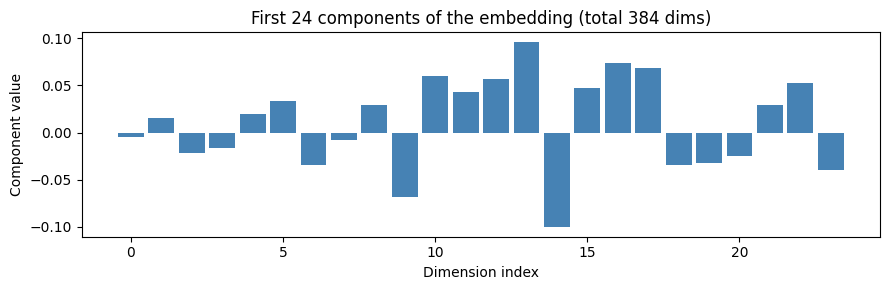


Random 2D projection (dims 34, 297): (-0.0663, 0.0332)


In [6]:
import matplotlib.pyplot as plt

one_sentence = "Embeddings map text into a fixed-size vector for similarity search."
vec = model.encode([one_sentence], convert_to_numpy=True)[0]

print(f"Sentence: {one_sentence!r}")
print(f"dtype: {vec.dtype}, shape: {vec.shape}, norm: {np.linalg.norm(vec):.4f}")

# First 24 dimensions (enough to see structure without clutter)
n_show = 24
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(np.arange(n_show), vec[:n_show], color="steelblue", width=0.85)
ax.set_xlabel("Dimension index")
ax.set_ylabel("Component value")
ax.set_title(f"First {n_show} components of the embedding (total {vec.shape[0]} dims)")
plt.tight_layout()
plt.show()

# Optional: two random dimensions as a 2D stand-in for "projection"
rng = np.random.default_rng(42)
i, j = rng.choice(vec.shape[0], size=2, replace=False)
print(f"\nRandom 2D projection (dims {i}, {j}): ({vec[i]:.4f}, {vec[j]:.4f})")

### What Step 1.1’s output means (outcome)

After you run the code cell above, you get **four concrete results**. Here is what each one is telling you:

| Output | Meaning in plain terms |
|--------|-------------------------|
| **`shape: (384,)`** | The model turned **one sentence** into **384 numbers**. That tuple is the **embedding vector** — like a fixed-width “feature row” you could store in a DB or compare in code. Different sentences → different 384-number rows (usually). |
| **`dtype: float32`** | Normal numeric array type; enough precision for similarity search. |
| **`norm: 1.0000` (≈ 1)** | This model **normalizes** embeddings to **unit length**. So each vector is an arrow of length 1 from the origin. That is why **cosine similarity** between two embeddings equals their **dot product** (Step 1.2). |
| **Bar chart (first 24 dims)** | You cannot plot all 384 axes. The chart is only a **peek** at 24 coordinates — small positive/negative **weights**. You do **not** need to interpret bar 17 vs bar 18; the idea is: the **whole** 384 values together encode “what this sentence is about” for the model. |
| **Random 2D projection** | Two **randomly chosen** dimensions (e.g. dims 34 and 297) printed as `(x, y)`. This is **not** a meaningful 2D map of meaning — it is a toy reminder that the real object is **384-dimensional** and any 2D slice is incomplete. |

**Outcome for the rest of Phase 1:** you have confirmed the pipeline **`text → model.encode → np array of fixed size`**. Later steps **chunk** documents, **encode** each chunk the same way, then **rank** chunks by how “aligned” their vectors are with the **query** vector — that ranking is your retrieval step before RAG.

### 1.2 — Paraphrases vs unrelated (cosine similarity)

**Cosine similarity** of two vectors \(a, b\): \(\cos\theta = \frac{a\cdot b}{\|a\|\|b\|}\). For **unit** vectors, this equals the dot product. Values near **1** → same direction; near **0** → unrelated; negative → opposite-ish direction.

Encode several sentences at once and compare **pairwise** cosines to the first sentence (the “anchor”).

In [ ]:
import numpy as np  # safe if this cell runs without re-running Step 0

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float64).ravel()
    b = np.asarray(b, dtype=np.float64).ravel()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


sentences = [
    # anchor
    "The meeting was rescheduled to next Tuesday afternoon.",
    # paraphrases / same situation
    "They moved the meeting to Tuesday after lunch.",
    "The appointment got pushed to the following Tuesday.",
    # unrelated
    "Marinara sauce needs good tomatoes, garlic, and olive oil.",
    "HNSW builds a graph to search vectors approximately fast.",
]

emb = model.encode(sentences, convert_to_numpy=True)
anchor = emb[0]

print(f"Anchor: {sentences[0]!r}\n")
print(f"{'Compared sentence':<62} | cos sim")
print("-" * 78)
for i, (text, v) in enumerate(zip(sentences, emb, strict=True)):
    # Calculate cosine similarity between the anchor embedding and the current sentence embedding.
    # This quantifies how similar the two sentences are in the model's representation.
    sim = cosine_sim(anchor, v)
    tag = "(anchor)" if i == 0 else ""
    print(f"{text[:62]:<62} | {sim:+.4f} {tag}")

Anchor: 'The meeting was rescheduled to next Tuesday afternoon.'

Compared sentence                                              | cos sim
------------------------------------------------------------------------------
The meeting was rescheduled to next Tuesday afternoon.         | +1.0000 (anchor)
They moved the meeting to Tuesday after lunch.                 | +0.7434 
The appointment got pushed to the following Tuesday.           | +0.5907 
Marinara sauce needs good tomatoes, garlic, and olive oil.     | -0.0076 
HNSW builds a graph to search vectors approximately fast.      | -0.0201 


### 1.3 — Checkpoint: synonym swaps (do vectors get closer?)

**Question:** If you replace a word with a **synonym**, does the new sentence’s embedding move **closer** to the original?

Below: for each pair, we report \(\cos(\text{embed}(A), \text{embed}(B))\) where \(B\) is a synonym swap of \(A\). **High** cosine ⇒ close in embedding space. Compare each to an **unrelated** control of similar length.

In [8]:
synonym_pairs = [
    (
        "Our fleet tracks each automobile by VIN at the depot.",
        "Our fleet tracks each car by VIN at the depot.",
        "Our fleet tracks each sandwich by VIN at the depot.",  # absurd control
    ),
    (
        "She purchased an automobile for her daily commute.",
        "She purchased a vehicle for her daily commute.",
        "She purchased an algorithm for her daily commute.",
    ),
    (
        "The physician recommended rest and hydration.",
        "The doctor recommended rest and hydration.",
        "The volcano recommended rest and hydration.",
    ),
]

print("Synonym swap vs unrelated control (cosine similarity to the first sentence)\n")
for original, synonymed, unrelated in synonym_pairs:
    e0, e1, e2 = model.encode([original, synonymed, unrelated], convert_to_numpy=True)
    sim_syn = cosine_sim(e0, e1)
    sim_unrel = cosine_sim(e0, e2)
    print(f"A: {original}")
    print(f"B (synonym): {synonymed}  → cos(A,B) = {sim_syn:.4f}")
    print(f"C (control): {unrelated}  → cos(A,C) = {sim_unrel:.4f}")
    print(f"Closer with synonym than control? {sim_syn > sim_unrel}\n")

print(
    "Takeaway: for these examples, synonym replacements usually land much closer than nonsense controls.\n"
    "It is not guaranteed for every word pair—polysemy, rare senses, and training data all matter."
)

Synonym swap vs unrelated control (cosine similarity to the first sentence)

A: Our fleet tracks each automobile by VIN at the depot.
B (synonym): Our fleet tracks each car by VIN at the depot.  → cos(A,B) = 0.9824
C (control): Our fleet tracks each sandwich by VIN at the depot.  → cos(A,C) = 0.8199
Closer with synonym than control? True

A: She purchased an automobile for her daily commute.
B (synonym): She purchased a vehicle for her daily commute.  → cos(A,B) = 0.9656
C (control): She purchased an algorithm for her daily commute.  → cos(A,C) = 0.7641
Closer with synonym than control? True

A: The physician recommended rest and hydration.
B (synonym): The doctor recommended rest and hydration.  → cos(A,B) = 0.9703
C (control): The volcano recommended rest and hydration.  → cos(A,C) = 0.6376
Closer with synonym than control? True

Takeaway: for these examples, synonym replacements usually land much closer than nonsense controls.
It is not guaranteed for every word pair—polysemy, rare 

## Step 2 — Cosine similarity and top-k retrieval (concept + core practice)

**Idea:** Treat each chunk embedding as a **unit vector** from the origin (this model L2-normalizes). **Cosine similarity** = \(\cos(\theta)\) = dot product for unit vectors. Rank every chunk by similarity to the **query** embedding; keep **top-k** (here \(k=5\) by default).

```mermaid
flowchart TB
  subgraph space [Embedding space — sketch]
    O((Origin))
    Q[Query vector q]
    C1[Chunk c1]
    C2[Chunk c2]
    O -.-> Q
    O -.-> C1
    O -.-> C2
  end
  Q --> S1["cos(q,c1)"]
  C1 --> S1
  Q --> S2["cos(q,c2)"]
  C2 --> S2
  S1 --> RANK[Sort all scores]
  S2 --> RANK
  RANK --> TOPK[Take top-k chunks]
```

**Practice (this section):**

1. **Chunk** corpus with a **simple** fixed-character window (overlap optional) — intentionally dumb; Phase 2 refines chunking.
2. **Embed** all chunks + one **query**.
3. **Similarity:** cosine between query and each chunk (normalized dot product).
4. **Top-k:** sort descending, take \(k\).
5. **Inspect:** print scores next to chunk text (and source file).

**Measure:** wall time for **embedding all chunks** and for **brute-force** similarity over all chunks (baseline before any ANN in Step 3).

**Depends on:** Step 0 (`model`, `REPO_ROOT`, `corpus_dir`) and Step 1’s `cosine_sim` helper (re-run notebook from top if needed).

### 2.1 — Chunk corpus (fixed character window)

We load each `*.md` under `data/phase1/` except `README.md` (meta). Chunks are **character slices** with overlap so sentences are not always cut at arbitrary boundaries.


In [9]:
from dataclasses import dataclass


def chunk_text(text: str, max_chars: int = 400, overlap: int = 80) -> list[str]:
    """Simple Phase-1 chunker: fixed char window with overlap (no tokenizer)."""
    text = text.strip()
    if not text:
        return []
    chunks: list[str] = []
    start = 0
    n = len(text)
    while start < n:
        end = min(start + max_chars, n)
        piece = text[start:end].strip()
        if piece:
            chunks.append(piece)
        if end >= n:
            break
        start = max(end - overlap, start + 1)
    return chunks


@dataclass(frozen=True)
class Chunk:
    text: str
    source_file: str
    chunk_index: int


corpus_paths = sorted(
    p for p in corpus_dir.glob("*.md") if p.name != "README.md"
)
all_chunks: list[Chunk] = []
for path in corpus_paths:
    raw = path.read_text(encoding="utf-8")
    for j, piece in enumerate(chunk_text(raw)):
        all_chunks.append(Chunk(text=piece, source_file=path.name, chunk_index=j))

print(f"Documents (excl. README): {len(corpus_paths)}")
print(f"Total chunks: {len(all_chunks)}")
print("\nFirst 3 chunk previews:")
for c in all_chunks[:3]:
    preview = c.text.replace("\n", " ")[:120]
    print(f"  [{c.source_file} #{c.chunk_index}] {preview}...")

Documents (excl. README): 8
Total chunks: 28

First 3 chunk previews:
  [01_embeddings_intro.md #0] # Embeddings as semantic fingerprints  An **embedding** maps text into a fixed-length vector of real numbers. The model ...
  [01_embeddings_intro.md #1] mmon score is **cosine similarity**: it measures alignment of direction (angle), not raw distance along the vector.  **T...
  [02_embeddings_intro_paraphrase.md #0] # Semantic vectors (paraphrased)  **Semantic embeddings** turn language into a numeric vector with a fixed size. Models ...


### 2.2 — Embed all chunks + query (timed)

**Query** is chosen to match content in the corpus (ANN / HNSW sketch + RAG notes) so top-k inspection is meaningful.


In [10]:
import time

# Question that should pull from ANN / vector-search themed docs
QUERY_STEP2 = (
    "How does approximate nearest neighbor search trade speed for recall, "
    "and what role does a graph play?"
)

t0 = time.perf_counter()
chunk_texts = [c.text for c in all_chunks]
emb_chunks = model.encode(chunk_texts, convert_to_numpy=True)
elapsed_embed_chunks = time.perf_counter() - t0

t0 = time.perf_counter()
emb_query = model.encode([QUERY_STEP2], convert_to_numpy=True)[0]
elapsed_embed_query = time.perf_counter() - t0

print(f"Query: {QUERY_STEP2!r}\n")
print(
    f"Embed {len(all_chunks)} chunks: {elapsed_embed_chunks * 1000:.2f} ms "
    f"  (shape {emb_chunks.shape})"
)
print(f"Embed query: {elapsed_embed_query * 1000:.2f} ms  (shape {emb_query.shape})")

Query: 'How does approximate nearest neighbor search trade speed for recall, and what role does a graph play?'

Embed 28 chunks: 431.51 ms   (shape (28, 384))
Embed query: 64.18 ms  (shape (384,))


### 2.3 — Brute-force cosine scores, top-k, inspect

`all-MiniLM-L6-v2` outputs **L2-normalized** vectors, so \(\cos(q, c_i) = q \cdot c_i\). Scoring all chunks is one matrix–vector product: full linear scan (exact search baseline).


In [11]:
TOP_K = 5

t0 = time.perf_counter()
# Unit vectors → cosine similarity = dot product (full scan over chunks)
scores = emb_chunks @ emb_query.astype(np.float64)
elapsed_bf = time.perf_counter() - t0

order = np.argsort(-scores)
top_idx = order[:TOP_K]

print(
    f"Brute-force similarity (all {len(scores)} chunks): "
    f"{elapsed_bf * 1000:.4f} ms\n"
)
print(f"Top-{TOP_K} chunks by cosine (same as dot for unit norms):\n")
for rank, i in enumerate(top_idx, start=1):
    c = all_chunks[int(i)]
    bar = scores[int(i)]
    preview = c.text.replace("\n", " ")
    if len(preview) > 220:
        preview = preview[:220] + "…"
    print(f"{rank}. score={bar:.4f}  [{c.source_file} chunk {c.chunk_index}]")
    print(f"   {preview}\n")

# Spot-check: rank-1 score matches explicit cosine_sim from Step 1 (if ran)
_cos = globals().get("cosine_sim")
if _cos is not None:
    check = _cos(emb_query, emb_chunks[int(top_idx[0])])
    print(f"Spot-check cosine_sim vs dot for rank-1 chunk: {check:.6f} ≈ {scores[int(top_idx[0])]:.6f}")
else:
    print("(Run Step 1 to define cosine_sim for the spot-check line above.)")

Brute-force similarity (all 28 chunks): 0.0821 ms

Top-5 chunks by cosine (same as dot for unit norms):

1. score=0.5947  [03_ann_hnsw_sketch.md chunk 15]
   *true* top-k neighbors, how many appear in *your* top-k (or in a candidate pool before reranking). | | **efSearch** (HNSW) | Larger → explores more nodes → **higher recall**, **slower** queries. | | **M** (HNSW) | Roughl…

2. score=0.5697  [03_ann_hnsw_sketch.md chunk 5]
   an **index**) so that at query time you **do not** visit all `N` points. You follow **hints**—“likely neighbors”—and stop early.  - **Pros:** Query time often sublinear or much smaller constant factors; essential at huge…

3. score=0.5069  [03_ann_hnsw_sketch.md chunk 0]
   # Approximate nearest neighbors (ANN) and HNSW — elaborated  You store **many chunk embeddings** (thousands to billions). A **nearest-neighbor search** answers: *which stored vectors are closest to this query vector?* “C…

4. score=0.4895  [03_ann_hnsw_sketch.md chunk 17]
   ## 5. One-line s